# Week 14: Mini Project — Sensor Log Summary — PHASE 3: Build a checkable report — Complete Worked Solutions

For students who have attempted the matching weekly notebook. Read the problem,
explain the steps aloud, then compare your code with this reference. Other correct
implementations are possible. These are private self-study examples, not submitted grades.

Run cells from top to bottom in a fresh Python 3 notebook. Every numbered exercise
has a worked solution and representative checks.
`assert condition` raises an error if a check fails; a passing check produces no output.
Assertions here verify selected cases, not every possible input.

**Prerequisites:** loops, lists, dictionaries (Week 7), functions with tuple returns (Weeks 9–10),
`try/except` (Week 11) and files (Week 12). Exercise 12 also uses matplotlib (Week 13).
File tasks create their own small sample files in the runtime's current working directory.
No live keyboard input or external downloads are needed.

**Türkçe:** Önce kendiniz deneyin; sonra adımları ve sınır durumlarını karşılaştırın.
Doğru sonuç kadar, neden o sonucu aldığınızı açıklamak da önemlidir.


## Reading the worked solutions

Each section gives the problem, a plan, Python code, and an expected result or checks.
Try your own answer first. After comparing, close this notebook and solve a changed example.

An `assert condition` line checks that a result matches an expectation. If the condition is false,
Python raises `AssertionError`; it means that check failed. For decimal calculations, a check such
as `abs(actual - expected) < 0.001` allows a small rounding difference.

Some examples run several small test cases. A pair `(input_value, expected_result)` keeps an input
beside its expected answer. In `for value, expected in cases`, Python takes the two parts of each
pair and gives them those names. Follow the calculation inside the loop for one case at a time.

**Türkçe:** `assert`, beklenen sonuç ile gerçek sonucu karşılaştırır. Test başarısızsa önce girdiyi
ve ara değerleri incele. Birden fazla örnek varsa önce yalnızca bir örneğin adımlarını takip et.

File examples create sample files in the current runtime folder. Use a separate runtime for your
own practice so the worked answers do not supply hidden variables to it.

[Week 14 lesson](../notebooks/Week_14.ipynb) · [All solutions](README.md) · [Course guide](../STUDY_GUIDE.md)


### Pipeline map and core milestones

EX1 creates the supplied data → EX2 reads it → EX3 validates one row → EX4 cleans all
rows → EX5–6 calculate statistics → EX7 builds a report → EX8–9 save both files →
EX10 joins everything in `main()`. These ten stages are core. EX11–12 are optional
extensions. Each function is defined before its first call, so run the cells in order.

The file schema is `timestamp,sensor,value`. Valid ranges are inclusive: temperature
−50…60 °C, humidity 0…100 %, pressure 800…1200 hPa.


## Exercise 1: Create the Supplied Sample Data (Easy)

Run the supplied dataset setup, producing `sensor_data.csv` with columns `timestamp,sensor,value`. This is an execution milestone, not a missing-code task. The full 20-record dataset is included so this solution runs independently.

### Reasoning and plan

Write the exact reference text to the file. Do not correct bad rows by hand: the later validation stage must find them. The 20 data rows include two empty readings, one non-numeric reading and two out-of-range readings. Reading the file back and counting lines confirms that it was saved.

**Türkçe:** Bozuk satırları elle düzeltmeyin; temizleme aşamasının bunları bulmasını istiyoruz.


In [1]:
# ✏️ [EX1] — worked solution
sample_data = """timestamp,sensor,value
2024-01-15 08:00,temp,22.5
2024-01-15 08:05,humidity,45.2
2024-01-15 08:10,temp,23.1
2024-01-15 08:15,pressure,1013.25
2024-01-15 08:20,temp,-999
2024-01-15 08:25,humidity,
2024-01-15 08:30,temp,22.8
2024-01-15 08:35,humidity,46.1
2024-01-15 08:40,pressure,abc
2024-01-15 08:45,temp,23.5
2024-01-15 08:50,humidity,44.8
2024-01-15 08:55,pressure,1012.80
2024-01-15 09:00,temp,24.0
2024-01-15 09:05,humidity,150.0
2024-01-15 09:10,pressure,1013.50
2024-01-15 09:15,temp,22.2
2024-01-15 09:20,humidity,43.5
2024-01-15 09:25,pressure,1011.90
2024-01-15 09:30,temp,
2024-01-15 09:35,humidity,47.3"""

with open("sensor_data.csv", "w") as f:
    f.write(sample_data)

with open("sensor_data.csv", "r") as f:
    lines = f.readlines()
print("sensor_data.csv created:", len(lines) - 1, "data rows plus a header")
assert lines[0].strip() == "timestamp,sensor,value"
assert len(lines) == 21
assert lines[6].strip() == "2024-01-15 08:25,humidity,"  # empty value kept for validation


sensor_data.csv created: 20 data rows plus a header


### Expected result

```text
sensor_data.csv created: 20 data rows plus a header
```

The assertions also check the cases named in the code.


## Exercise 2: Read and Parse the CSV (Easy)

Read `"sensor_data.csv"` and store all data rows in a list called `raw_data`. Each element is a list of 3 strings: `[timestamp, sensor, value]`.

### Reasoning and plan

Read the header line first so it is not treated as data. Every other line is stripped and split on the comma. The values stay as text; converting them is the validator's job. A blank value becomes an empty string, which is exactly what the next stage needs to see.

**Türkçe:** Okuma aşaması alanları ayırır; geçerlilik kontrolü sonraki aşamadır. Boş değer boş metin olarak kalır.


In [2]:
# ✏️ [EX2] — worked solution
def read_data(filename):
    rows = []
    with open(filename, "r") as f:
        header = f.readline().strip().split(",")
        for line in f:
            line = line.strip()
            if line == "":
                continue  # skip a blank last line if there is one
            rows.append(line.split(","))
    return header, rows

header, raw_data = read_data("sensor_data.csv")
print("Header:", header)
print("Total rows read:", len(raw_data))
print("First row:", raw_data[0])
print("Last row:", raw_data[-1])
assert header == ["timestamp", "sensor", "value"]
assert len(raw_data) == 20
assert raw_data[0] == ["2024-01-15 08:00", "temp", "22.5"]
assert raw_data[5] == ["2024-01-15 08:25", "humidity", ""]  # empty value survives as ''
assert all(len(row) == 3 for row in raw_data)


Header: ['timestamp', 'sensor', 'value']
Total rows read: 20
First row: ['2024-01-15 08:00', 'temp', '22.5']
Last row: ['2024-01-15 09:35', 'humidity', '47.3']


### Expected result

```text
Header: ['timestamp', 'sensor', 'value']
Total rows read: 20
First row: ['2024-01-15 08:00', 'temp', '22.5']
Last row: ['2024-01-15 09:35', 'humidity', '47.3']
```

The assertions also check the cases named in the code.


## Exercise 3: Validate a Single Row (Medium)

Write `validate_row(row)` that takes `[timestamp, sensor, value_text]` and returns `(True, "OK")`, `(False, "empty value")`, `(False, "non-numeric value: 'xxx'")` or `(False, "out of range: xxx")`.

### Reasoning and plan

Check the cheap condition first: an empty string. Then convert with `float()` inside `try/except ValueError`; the message keeps the original text so the reader can see what failed. Finally look up the sensor's `(low, high)` pair in the dictionary and test `low <= value <= high`. Every branch returns a two-item tuple, so the caller can always unpack it.

**Türkçe:** Sıra: boş mu → sayıya çeviriliyor mu → aralıkta mı. Geçerli negatif sıcaklık (`-10`) kabul edilir; `-999` aralık dışıdır.


In [3]:
# ✏️ [EX3] — worked solution
ranges = {"temp": (-50.0, 60.0), "humidity": (0.0, 100.0), "pressure": (800.0, 1200.0)}

def validate_row(row):
    timestamp, sensor, text = row
    text = text.strip()
    if text == "":
        return False, "empty value"
    try:
        value = float(text)
    except ValueError:
        return False, f"non-numeric value: '{text}'"
    low, high = ranges[sensor]
    if not low <= value <= high:
        return False, f"out of range: {value}"
    return True, "OK"

tests = [raw_data[0], raw_data[5], raw_data[8], raw_data[4], raw_data[13]]
for row in tests:
    print(f"{str(row):<42} -> {validate_row(row)}")

assert validate_row(["2024-01-15 08:00", "temp", "22.5"]) == (True, "OK")
assert validate_row(["2024-01-15 08:25", "humidity", ""]) == (False, "empty value")
assert validate_row(["2024-01-15 08:40", "pressure", "abc"]) == (False, "non-numeric value: 'abc'")
assert validate_row(["2024-01-15 08:20", "temp", "-999"]) == (False, "out of range: -999.0")
assert validate_row(["t", "temp", "-10"]) == (True, "OK")        # valid negative temperature
assert validate_row(["t", "humidity", "100.0"]) == (True, "OK")  # boundary is inclusive
assert validate_row(["t", "humidity", "100.1"])[0] is False


['2024-01-15 08:00', 'temp', '22.5']       -> (True, 'OK')
['2024-01-15 08:25', 'humidity', '']       -> (False, 'empty value')
['2024-01-15 08:40', 'pressure', 'abc']    -> (False, "non-numeric value: 'abc'")
['2024-01-15 08:20', 'temp', '-999']       -> (False, 'out of range: -999.0')
['2024-01-15 09:05', 'humidity', '150.0']  -> (False, 'out of range: 150.0')


### Expected result

```text
['2024-01-15 08:00', 'temp', '22.5']       -> (True, 'OK')
['2024-01-15 08:25', 'humidity', '']       -> (False, 'empty value')
['2024-01-15 08:40', 'pressure', 'abc']    -> (False, "non-numeric value: 'abc'")
['2024-01-15 08:20', 'temp', '-999']       -> (False, 'out of range: -999.0')
['2024-01-15 09:05', 'humidity', '150.0']  -> (False, 'out of range: 150.0')
```

The assertions also check the cases named in the code.


## Exercise 4: Clean the Data (Medium)

Using `validate_row()`, separate the data into `clean_data` (rows that passed) and `bad_data` (rows that failed, with row number and reason). Print a summary.

### Reasoning and plan

The cleaning loop makes no decisions of its own; it asks `validate_row` and sorts each row into one of two lists. `enumerate(..., start=1)` numbers the rows the way a person counts them. The two list lengths must add up to the input length, which is a cheap check that no row was lost.

**Türkçe:** Temizleme döngüsü karar üretmez; tek satır doğrulayıcısının kararını kullanıp veriyi iki listeye ayırır. `temiz + bozuk = toplam` olmalıdır.


In [4]:
# ✏️ [EX4] — worked solution
def clean_records(rows):
    clean = []
    bad = []
    for number, row in enumerate(rows, start=1):
        valid, reason = validate_row(row)
        if valid:
            clean.append(row)
        else:
            bad.append((number, row, reason))
    return clean, bad

clean_data, bad_data = clean_records(raw_data)
print("Data Cleaning Results")
print("=====================")
print(f"Total rows: {len(raw_data)}")
print(f"Clean rows: {len(clean_data)}")
print(f"Bad rows: {len(bad_data)}")
print()
print("Bad rows detail:")
for number, row, reason in bad_data:
    print(f"  Row {number}: {' | '.join(row)} -> {reason}")

assert len(clean_data) == 15 and len(bad_data) == 5
assert len(clean_data) + len(bad_data) == len(raw_data)
assert [number for number, row, reason in bad_data] == [5, 6, 9, 14, 19]
assert clean_records([]) == ([], [])  # edge case: no rows at all


Data Cleaning Results
Total rows: 20
Clean rows: 15
Bad rows: 5

Bad rows detail:
  Row 5: 2024-01-15 08:20 | temp | -999 -> out of range: -999.0
  Row 6: 2024-01-15 08:25 | humidity |  -> empty value
  Row 9: 2024-01-15 08:40 | pressure | abc -> non-numeric value: 'abc'
  Row 14: 2024-01-15 09:05 | humidity | 150.0 -> out of range: 150.0
  Row 19: 2024-01-15 09:30 | temp |  -> empty value


### Expected result

```text
Data Cleaning Results
=====================
Total rows: 20
Clean rows: 15
Bad rows: 5

Bad rows detail:
  Row 5: 2024-01-15 08:20 | temp | -999 -> out of range: -999.0
  Row 6: 2024-01-15 08:25 | humidity |  -> empty value
  Row 9: 2024-01-15 08:40 | pressure | abc -> non-numeric value: 'abc'
  Row 14: 2024-01-15 09:05 | humidity | 150.0 -> out of range: 150.0
  Row 19: 2024-01-15 09:30 | temp |  -> empty value
```

The assertions also check the cases named in the code.


## Exercise 5: Stats for One Sensor (Medium)

Write `compute_stats(data, sensor_name)` that takes the clean data list and a sensor name and returns a dictionary with `count`, `min`, `max` and `mean` for that sensor.

### Reasoning and plan

Filter by sensor name before any arithmetic so different units are never mixed. The values are converted with `float()`; they already passed validation, so no `try/except` is needed here. Temperature values sum to 138.1 over 6 readings, so the mean is 23.0166…, displayed as 23.02. The dictionary stores the full-precision mean.

**Türkçe:** Önce sensöre göre süz, sonra hesapla. Ortalamayı tam hassasiyetle sakla; yalnızca yazdırırken yuvarla.


In [5]:
# ✏️ [EX5] — worked solution
def compute_stats(data, sensor_name):
    values = []
    for row in data:
        if row[1] == sensor_name:
            values.append(float(row[2]))
    return {
        "count": len(values),
        "min": min(values),
        "max": max(values),
        "mean": sum(values) / len(values),
    }

temp_stats = compute_stats(clean_data, "temp")
print("Stats for temp:")
print("  count:", temp_stats["count"])
print("  min:", temp_stats["min"])
print("  max:", temp_stats["max"])
print(f"  mean: {temp_stats['mean']:.2f}")

assert temp_stats["count"] == 6
assert temp_stats["min"] == 22.2 and temp_stats["max"] == 24.0
assert abs(temp_stats["mean"] - 138.1 / 6) < 0.001
one = compute_stats([["t", "temp", "-10"]], "temp")   # edge case: a single reading
assert one == {"count": 1, "min": -10.0, "max": -10.0, "mean": -10.0}


Stats for temp:
  count: 6
  min: 22.2
  max: 24.0
  mean: 23.02


### Expected result

```text
Stats for temp:
  count: 6
  min: 22.2
  max: 24.0
  mean: 23.02
```

The assertions also check the cases named in the code.


## Exercise 6: Stats for All Sensors (Easy)

Use `compute_stats()` for all three sensors and store the results in a dictionary called `all_stats`.

### Reasoning and plan

The same function serves every sensor; the loop only changes the name. Storing each result under its sensor key keeps the three summaries separate. The counts 6 + 5 + 4 equal the 15 clean rows, which checks that no reading was dropped or counted twice.

**Türkçe:** Bir fonksiyonu üç sensörde yeniden kullanmak, üç ayrı ve tutarsız hesap yazmayı önler. Sayımlar 15 temiz satıra eşit olmalıdır.


In [6]:
# ✏️ [EX6] — worked solution
def stats_for_all(data):
    all_stats = {}
    for sensor in ["temp", "humidity", "pressure"]:
        all_stats[sensor] = compute_stats(data, sensor)
    return all_stats

all_stats = stats_for_all(clean_data)
print("Sensor Statistics")
print("=================")
for sensor, stats in all_stats.items():
    print()
    print(f"{sensor}:")
    print(f"  Readings: {stats['count']}")
    print(f"  Min: {stats['min']:.2f}, Max: {stats['max']:.2f}, Mean: {stats['mean']:.2f}")

assert [all_stats[s]["count"] for s in all_stats] == [6, 5, 4]
assert sum(all_stats[s]["count"] for s in all_stats) == len(clean_data)
assert abs(all_stats["humidity"]["mean"] - 45.38) < 0.001
assert abs(all_stats["pressure"]["mean"] - 1012.8625) < 0.001


Sensor Statistics

temp:
  Readings: 6
  Min: 22.20, Max: 24.00, Mean: 23.02

humidity:
  Readings: 5
  Min: 43.50, Max: 47.30, Mean: 45.38

pressure:
  Readings: 4
  Min: 1011.90, Max: 1013.50, Mean: 1012.86


### Expected result

```text
Sensor Statistics
=================

temp:
  Readings: 6
  Min: 22.20, Max: 24.00, Mean: 23.02

humidity:
  Readings: 5
  Min: 43.50, Max: 47.30, Mean: 45.38

pressure:
  Readings: 4
  Min: 1011.90, Max: 1013.50, Mean: 1012.86
```

The assertions also check the cases named in the code.


## Exercise 7: Generate Summary Report (Medium)

Write `generate_report(all_stats, total_rows, clean_count, bad_count)` that returns the formatted summary report as one string.

### Reasoning and plan

Separate calculation from display: the function receives finished numbers and only formats them. Collecting lines in a list and joining them once is easier to read than many `+=` steps. Data quality is 15/20 × 100 = 75.0 %. The function returns the text, so the same string can be printed now and saved in Exercise 9.

**Türkçe:** Rapor biçimlendirmesi hesabı değiştirmez. Satırları listede topla, sonunda `"\n".join` ile birleştir.


In [7]:
# ✏️ [EX7] — worked solution
def generate_report(all_stats, total_rows, clean_count, bad_count):
    quality = 100 * clean_count / total_rows
    lines = []
    lines.append("======================================")
    lines.append("    SENSOR LOG SUMMARY REPORT")
    lines.append("======================================")
    lines.append("")
    lines.append("DATA OVERVIEW")
    lines.append("-------------")
    lines.append(f"Total readings:   {total_rows}")
    lines.append(f"Valid readings:   {clean_count}")
    lines.append(f"Invalid readings: {bad_count}")
    lines.append(f"Data quality:     {quality:.1f}%")
    for sensor, stats in all_stats.items():
        lines.append("")
        lines.append(f"SENSOR: {sensor}")
        lines.append("-------------")
        lines.append(f"  Readings: {stats['count']}")
        lines.append(f"  Min:      {stats['min']:.2f}")
        lines.append(f"  Max:      {stats['max']:.2f}")
        lines.append(f"  Mean:     {stats['mean']:.2f}")
    lines.append("")
    lines.append("======================================")
    return "\n".join(lines)

report = generate_report(all_stats, len(raw_data), len(clean_data), len(bad_data))
print(report)

assert "Data quality:     75.0%" in report
assert "Mean:     23.02" in report and "Mean:     1012.86" in report
assert report.count("SENSOR:") == 3
small = generate_report({"temp": compute_stats([["t", "temp", "5"]], "temp")}, 1, 1, 0)
assert "Data quality:     100.0%" in small and small.count("SENSOR:") == 1  # edge case: one row


    SENSOR LOG SUMMARY REPORT

DATA OVERVIEW
-------------
Total readings:   20
Valid readings:   15
Invalid readings: 5
Data quality:     75.0%

SENSOR: temp
-------------
  Readings: 6
  Min:      22.20
  Max:      24.00
  Mean:     23.02

SENSOR: humidity
-------------
  Readings: 5
  Min:      43.50
  Max:      47.30
  Mean:     45.38

SENSOR: pressure
-------------
  Readings: 4
  Min:      1011.90
  Max:      1013.50
  Mean:     1012.86



### Expected result

```text
======================================
    SENSOR LOG SUMMARY REPORT
======================================

DATA OVERVIEW
-------------
Total readings:   20
Valid readings:   15
Invalid readings: 5
Data quality:     75.0%

SENSOR: temp
-------------
  Readings: 6
  Min:      22.20
  Max:      24.00
  Mean:     23.02

SENSOR: humidity
-------------
  Readings: 5
  Min:      43.50
  Max:      47.30
  Mean:     45.38

SENSOR: pressure
-------------
  Readings: 4
  Min:      1011.90
  Max:      1013.50
  Mean:     1012.86

======================================
```

The assertions also check the cases named in the code.


## Exercise 8: Write Clean CSV (Easy)

Write `clean_data` to `"sensor_data_clean.csv"` with the header row. Then read the file back and print the first 5 lines to verify.

### Reasoning and plan

Write the header first, then one line per clean row. `",".join(row)` turns the three fields back into CSV text, and the `"\n"` ends the line. Reading the file back is the real check: the saved lines must be the header plus exactly the 15 clean rows.

**Türkçe:** Dosyayı yeniden okuyup satırları karşılaştırın; yalnızca ekrandaki başarı mesajına güvenmeyin.


In [8]:
# ✏️ [EX8] — worked solution
def write_clean_csv(data, filename):
    with open(filename, "w") as f:
        f.write("timestamp,sensor,value\n")
        for row in data:
            f.write(",".join(row) + "\n")

write_clean_csv(clean_data, "sensor_data_clean.csv")
print(f"Clean data written to sensor_data_clean.csv ({len(clean_data)} rows + header)")
print()
print("First 5 lines of clean file:")
with open("sensor_data_clean.csv", "r") as f:
    saved_lines = f.readlines()
for line in saved_lines[:5]:
    print("  " + line.strip())

assert len(saved_lines) == 16
assert saved_lines[0].strip() == "timestamp,sensor,value"
saved_header, saved_rows = read_data("sensor_data_clean.csv")
assert saved_rows == clean_data
assert all(validate_row(row)[0] for row in saved_rows)  # every saved row is still valid


Clean data written to sensor_data_clean.csv (15 rows + header)

First 5 lines of clean file:
  timestamp,sensor,value
  2024-01-15 08:00,temp,22.5
  2024-01-15 08:05,humidity,45.2
  2024-01-15 08:10,temp,23.1
  2024-01-15 08:15,pressure,1013.25


### Expected result

```text
Clean data written to sensor_data_clean.csv (15 rows + header)

First 5 lines of clean file:
  timestamp,sensor,value
  2024-01-15 08:00,temp,22.5
  2024-01-15 08:05,humidity,45.2
  2024-01-15 08:10,temp,23.1
  2024-01-15 08:15,pressure,1013.25
```

The assertions also check the cases named in the code.


## Exercise 9: Write Report to File (Easy)

Write the report string from Exercise 7 to `"sensor_report.txt"`. Print a confirmation and read the file back to verify.

### Reasoning and plan

Saving is one `write()` call with the finished text. The check compares the whole saved text with the string in memory, not just a few lines. Producing the text and saving it are separate stages; both are project deliverables.

**Türkçe:** Metni üretmek ile dosyaya kaydetmek ayrı aşamalardır; kaydedilen metin bellektekiyle aynı olmalıdır.


In [9]:
# ✏️ [EX9] — worked solution
def write_report(report, filename):
    with open(filename, "w") as f:
        f.write(report)

write_report(report, "sensor_report.txt")
print("Report written to sensor_report.txt")
print()
print("--- sensor_report.txt ---")
with open("sensor_report.txt", "r") as f:
    saved_report = f.read()
print(saved_report)

assert saved_report == report
assert saved_report.startswith("======") and "SENSOR: pressure" in saved_report
assert len(saved_report.splitlines()) == len(report.splitlines())


Report written to sensor_report.txt

--- sensor_report.txt ---
    SENSOR LOG SUMMARY REPORT

DATA OVERVIEW
-------------
Total readings:   20
Valid readings:   15
Invalid readings: 5
Data quality:     75.0%

SENSOR: temp
-------------
  Readings: 6
  Min:      22.20
  Max:      24.00
  Mean:     23.02

SENSOR: humidity
-------------
  Readings: 5
  Min:      43.50
  Max:      47.30
  Mean:     45.38

SENSOR: pressure
-------------
  Readings: 4
  Min:      1011.90
  Max:      1013.50
  Mean:     1012.86



### Expected result

```text
Report written to sensor_report.txt

--- sensor_report.txt ---
======================================
    SENSOR LOG SUMMARY REPORT
======================================

DATA OVERVIEW
-------------
Total readings:   20
Valid readings:   15
Invalid readings: 5
Data quality:     75.0%

SENSOR: temp
-------------
  Readings: 6
  Min:      22.20
  Max:      24.00
  Mean:     23.02

SENSOR: humidity
-------------
  Readings: 5
  Min:      43.50
  Max:      47.30
  Mean:     45.38

SENSOR: pressure
-------------
  Readings: 4
  Min:      1011.90
  Max:      1013.50
  Mean:     1012.86

======================================
```

The assertions also check the cases named in the code.


## Exercise 10: The Complete Program (Medium)

Write a `main()` function that reads `sensor_data.csv`, validates and cleans the data, computes statistics, generates the report, writes both output files and prints a final status message. Call `main()` at the end.

### Reasoning and plan

`main()` contains no new logic: it calls the tested functions in order and prints progress between the stages. Because each stage returns its result, `main()` can pass one stage's output into the next. After the run, both files are read back and compared with the printed counts. The optional plot uses matplotlib from Week 13; it is not part of the core task.

**Türkçe:** Ana fonksiyon aşamaları sırayla çağırır ve ilerlemeyi yazdırır; yeni mantık içermez. Çalıştıktan sonra iki dosyayı yeniden okuyup sayıları karşılaştırın.


Sensor Log Summary Tool

[1/6] Reading sensor_data.csv...
      Found 20 data rows.

[2/6] Cleaning data...
      Valid: 15 | Invalid: 5

[3/6] Computing statistics...
      Processed 3 sensors.

[4/6] Generating report...
      Report ready.

[5/6] Writing sensor_data_clean.csv...
      Done.

[6/6] Writing sensor_report.txt...
      Done.

All tasks completed successfully!


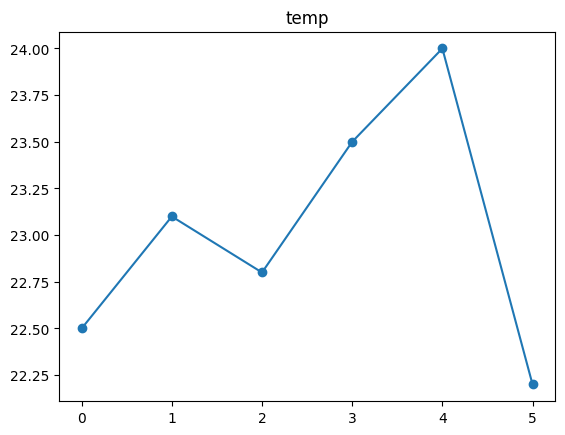

In [10]:
# ✏️ [EX10] — worked solution
def main():
    print("Sensor Log Summary Tool")
    print("=======================")
    print()
    print("[1/6] Reading sensor_data.csv...")
    header, rows = read_data("sensor_data.csv")
    print(f"      Found {len(rows)} data rows.")
    print()
    print("[2/6] Cleaning data...")
    clean, bad = clean_records(rows)
    print(f"      Valid: {len(clean)} | Invalid: {len(bad)}")
    print()
    print("[3/6] Computing statistics...")
    stats = stats_for_all(clean)
    print(f"      Processed {len(stats)} sensors.")
    print()
    print("[4/6] Generating report...")
    text = generate_report(stats, len(rows), len(clean), len(bad))
    print("      Report ready.")
    print()
    print("[5/6] Writing sensor_data_clean.csv...")
    write_clean_csv(clean, "sensor_data_clean.csv")
    print("      Done.")
    print()
    print("[6/6] Writing sensor_report.txt...")
    write_report(text, "sensor_report.txt")
    print("      Done.")
    print()
    print("All tasks completed successfully!")
    return clean, bad, stats

clean, bad, stats = main()

# Checks: read both files back and compare with the counts printed above.
saved_header, saved_rows = read_data("sensor_data_clean.csv")
with open("sensor_report.txt", "r") as f:
    saved_report = f.read()
assert (len(saved_rows), len(bad)) == (15, 5)
assert saved_rows == clean
assert f"Valid readings:   {len(saved_rows)}" in saved_report
assert all(validate_row(row)[0] for row in saved_rows)   # edge case: nothing invalid was saved

# Optional plot (Week 13): one line for the temperature readings.
import matplotlib.pyplot as plt
temps = []
for row in clean:
    if row[1] == "temp":
        temps.append(float(row[2]))
plt.plot(temps, marker="o")
plt.title("temp")
plt.show()


### Expected result

```text
Sensor Log Summary Tool
=======================

[1/6] Reading sensor_data.csv...
      Found 20 data rows.

[2/6] Cleaning data...
      Valid: 15 | Invalid: 5

[3/6] Computing statistics...
      Processed 3 sensors.

[4/6] Generating report...
      Report ready.

[5/6] Writing sensor_data_clean.csv...
      Done.

[6/6] Writing sensor_report.txt...
      Done.

All tasks completed successfully!
```

A small line plot of the six temperature readings follows the text (optional Week 13 extra).

The assertions also check the cases named in the code.


## Exercise 11: BONUS — Date/Time Filtering and Robustness (Challenge)

**Part A.** Write `filter_by_time(data, start_time, end_time)` that returns the rows of the cleaned data whose timestamp is between the two limits (inclusive). **Part B.** Make `validate_row` robust: wrong field count, unknown sensor, `nan` and `inf` must return `(False, reason)` instead of crashing.

### Reasoning and plan

Part A filters `clean_data`, never the raw rows: the 08:40 `abc` record is already gone, so six of the seven raw timestamps in 08:30–09:00 remain. Timestamps in `YYYY-MM-DD HH:MM` form sort correctly as strings. Part B adds the structural checks before any indexing, and `math.isfinite()` catches `nan` and `inf`, which `float()` happily accepts.

**Türkçe:** Önce temizleme, sonra zaman filtresi. Sağlam doğrulayıcı alan sayısını ve sensör adını değere dokunmadan önce kontrol eder; `nan` için `math.isfinite()` gerekir.


In [11]:
# ✏️ [EX11] — worked solution
import math

def filter_by_time(data, start_time, end_time):
    selected = []
    for row in data:
        if start_time <= row[0] <= end_time:
            selected.append(row)
    return selected

start = "2024-01-15 08:30"
end = "2024-01-15 09:00"
filtered = filter_by_time(clean_data, start, end)
print(f"Filtering: {start} to {end}")
print(f"Found {len(filtered)} readings in time range.")
print()
print("Filtered data:")
for timestamp, sensor, value in filtered:
    print(f"  {timestamp} | {sensor:<9} | {value}")

assert len(filtered) == 6
assert [row[0][-5:] for row in filtered] == ["08:30", "08:35", "08:45", "08:50", "08:55", "09:00"]
assert filter_by_time(clean_data, start, start) == [["2024-01-15 08:30", "temp", "22.8"]]  # a single instant
assert filter_by_time([], start, end) == []                          # edge case: no data

def validate_row_robust(row):
    if len(row) != 3:
        return False, "expected exactly 3 fields"
    timestamp, sensor, text = row
    text = text.strip()
    if sensor not in ranges:
        return False, f"unknown sensor: '{sensor}'"
    if text == "":
        return False, "empty value"
    try:
        value = float(text)
    except ValueError:
        return False, f"non-numeric value: '{text}'"
    if not math.isfinite(value):
        return False, f"non-finite value: '{text}'"
    low, high = ranges[sensor]
    if not low <= value <= high:
        return False, f"out of range: {value}"
    return True, "OK"

robust_tests = [["t", "temp"], ["t", "light", "12"], ["t", "temp", "nan"], ["t", "temp", "inf"], ["t", "temp", "-10"]]
for row in robust_tests:
    print(f"{str(row):<24} -> {validate_row_robust(row)}")
assert validate_row_robust(["t", "temp"]) == (False, "expected exactly 3 fields")
assert validate_row_robust(["t", "light", "12"]) == (False, "unknown sensor: 'light'")
assert validate_row_robust(["t", "temp", "nan"])[0] is False
assert validate_row_robust(["t", "temp", "-10"]) == (True, "OK")
for row in raw_data:  # the robust version agrees with the simple one on the real file
    assert validate_row_robust(row) == validate_row(row)


Filtering: 2024-01-15 08:30 to 2024-01-15 09:00
Found 6 readings in time range.

Filtered data:
  2024-01-15 08:30 | temp      | 22.8
  2024-01-15 08:35 | humidity  | 46.1
  2024-01-15 08:45 | temp      | 23.5
  2024-01-15 08:50 | humidity  | 44.8
  2024-01-15 08:55 | pressure  | 1012.80
  2024-01-15 09:00 | temp      | 24.0
['t', 'temp']            -> (False, 'expected exactly 3 fields')
['t', 'light', '12']     -> (False, "unknown sensor: 'light'")
['t', 'temp', 'nan']     -> (False, "non-finite value: 'nan'")
['t', 'temp', 'inf']     -> (False, "non-finite value: 'inf'")
['t', 'temp', '-10']     -> (True, 'OK')


### Expected result

```text
Filtering: 2024-01-15 08:30 to 2024-01-15 09:00
Found 6 readings in time range.

Filtered data:
  2024-01-15 08:30 | temp      | 22.8
  2024-01-15 08:35 | humidity  | 46.1
  2024-01-15 08:45 | temp      | 23.5
  2024-01-15 08:50 | humidity  | 44.8
  2024-01-15 08:55 | pressure  | 1012.80
  2024-01-15 09:00 | temp      | 24.0
['t', 'temp']            -> (False, 'expected exactly 3 fields')
['t', 'light', '12']     -> (False, "unknown sensor: 'light'")
['t', 'temp', 'nan']     -> (False, "non-finite value: 'nan'")
['t', 'temp', 'inf']     -> (False, "non-finite value: 'inf'")
['t', 'temp', '-10']     -> (True, 'OK')
```

The assertions also check the cases named in the code.


## Exercise 12: BONUS — Plot Each Sensor with matplotlib (Challenge)

Draw one subplot per sensor from `clean_data` (x = reading number, y = value, title = sensor name), save the figure as `sensor_plot.png`, and print a confirmation.

### Reasoning and plan

Group the values per sensor exactly as `compute_stats` does, then give each list its own axis so the different units never share a y-axis. `plt.subplots(1, 3)` returns the figure and a list of three axes. Save the figure before `plt.show()`, because showing can clear it. Reading the PNG's size back checks that a real file was written.

**Türkçe:** Her sensör kendi eksenine çizilir; birimler farklı olduğu için tek eksende karşılaştırılmaz. `savefig` çağrısı `show`dan önce gelmelidir.


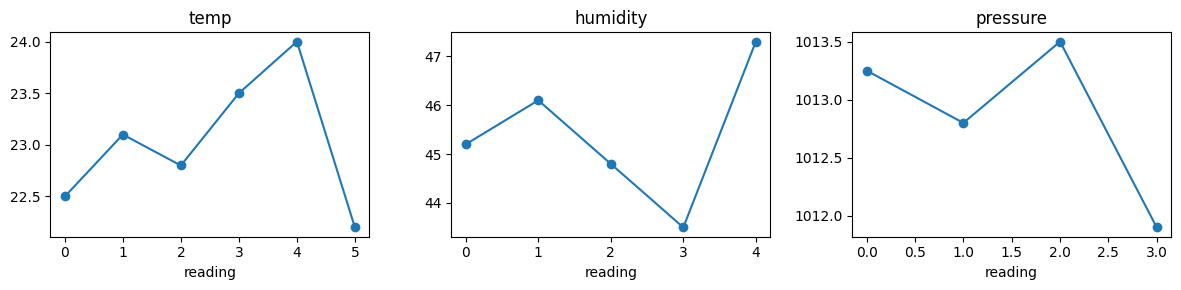

temp: 6 points | humidity: 5 points | pressure: 4 points
Saved sensor_plot.png


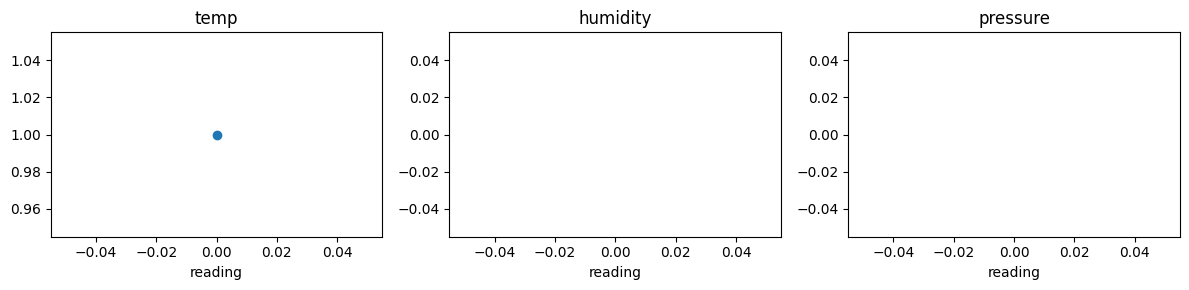

temp: 1 points | humidity: 0 points | pressure: 0 points
Saved one_point.png


In [12]:
# ✏️ [EX12] — worked solution
import os
import matplotlib.pyplot as plt

def plot_sensors(data, filename):
    sensors = ["temp", "humidity", "pressure"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    counts = []
    for i, sensor in enumerate(sensors):
        values = []
        for row in data:
            if row[1] == sensor:
                values.append(float(row[2]))
        axes[i].plot(values, marker="o")
        axes[i].set_title(sensor)
        axes[i].set_xlabel("reading")
        counts.append(f"{sensor}: {len(values)} points")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(" | ".join(counts))
    print(f"Saved {filename}")
    return counts

counts = plot_sensors(clean_data, "sensor_plot.png")
assert counts == ["temp: 6 points", "humidity: 5 points", "pressure: 4 points"]
assert os.path.exists("sensor_plot.png") and os.path.getsize("sensor_plot.png") > 1000
assert plot_sensors([["t", "temp", "1"]], "one_point.png")[0] == "temp: 1 points"  # edge case: one reading


### Expected result

```text
temp: 6 points | humidity: 5 points | pressure: 4 points
Saved sensor_plot.png
temp: 1 points | humidity: 0 points | pressure: 0 points
Saved one_point.png
```

The three-panel figure is displayed after the first two lines; the edge-case call draws a second, mostly empty figure.

The assertions also check the cases named in the code.


## Review before moving on

Choose one solution, change one input, and predict the new result before rerunning it.
Explain which branch, validation rule, or function contract makes the answer correct.
A familiar answer copied unchanged is weaker evidence than a new case you can explain.

**Türkçe:** Bir girdiyi değiştirin, çalıştırmadan sonucu tahmin edin ve farkı açıklayın.
